# Classical time-series statistics by hand (no statsmodels)

Everything here is done with NumPy, pandas, SciPy and sklearn only. That is deliberate:
in the interview you will not have `statsmodels`, and being able to compute an ACF or
fit an AR model with `np.linalg.lstsq` shows you understand what the library would do.

**What's in here**
- ACF and PACF by hand, and the white-noise band
- stationarity intuition: rolling moments, variance ratio, differencing, log transform
- seasonal decomposition by hand vs regression decomposition
- AR models via OLS: one-step vs recursive multi-step, seasonal lags
- exponential smoothing with `ewm` and a manual loop, choosing alpha
- cross-correlation and lead-lag, a Granger-style nested F-test
- spurious regression of random walks
- volatility clustering in price changes
- error vs forecast horizon for several simple models

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize_scalar
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
cons = df["consumption_mwh"]
price = df["price_eur_mwh"]
temp = df["temp_c"]
print(df.shape, df.index.min(), df.index.max())

(17520, 5) 2022-01-01 00:00:00+00:00 2023-12-31 23:00:00+00:00


## 1. Autocorrelation function (ACF)

Two estimators. `np.corrcoef(x[k:], x[:-k])` re-centres and re-scales each lagged
segment separately (the "unbiased-looking" version). The standard ACF used by every
library divides the lag-k autocovariance by the lag-0 variance using **one** mean and
**one** denominator `n`, which guarantees a positive-definite sequence.

**Pitfall:** the two agree for short lags and long series, but differ noticeably when
`k` is a sizeable fraction of `n`. Know which one you computed.

In [2]:
def acf(x, nlags):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    denom = np.dot(x, x)
    return np.array([1.0] + [np.dot(x[k:], x[:-k]) / denom for k in range(1, nlags + 1)])

def acf_corrcoef(x, nlags):
    x = np.asarray(x, dtype=float)
    return np.array([1.0] + [np.corrcoef(x[k:], x[:-k])[0, 1] for k in range(1, nlags + 1)])

r_std = acf(cons, 200)
r_cc = acf_corrcoef(cons, 200)
pd.DataFrame({"lag": [1, 2, 24, 48, 168], "acf_standard": r_std[[1, 2, 24, 48, 168]],
              "acf_corrcoef": r_cc[[1, 2, 24, 48, 168]]}).round(4)

,lag,acf_standard,acf_corrcoef
0,1,0.9350,0.9350
1,2,0.7814,0.7814
2,24,0.9135,0.9143
3,48,0.8658,0.8672
4,168,0.9198,0.9304


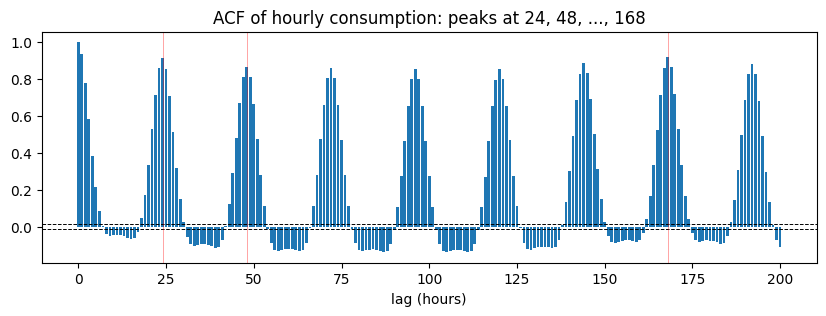

white-noise band ±0.0148; ACF at lag 24 = 0.913, lag 168 = 0.920


In [3]:
n = len(cons)
band = 1.96 / np.sqrt(n)
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(201), r_std, width=0.8)
ax.axhline(band, color="k", lw=0.7, ls="--"); ax.axhline(-band, color="k", lw=0.7, ls="--")
for k in (24, 48, 168):
    ax.axvline(k, color="r", lw=0.5, alpha=0.5)
ax.set_title("ACF of hourly consumption: peaks at 24, 48, ..., 168"); ax.set_xlabel("lag (hours)")
plt.show()
print(f"white-noise band ±{band:.4f}; ACF at lag 24 = {r_std[24]:.3f}, lag 168 = {r_std[168]:.3f}")

**Pitfall:** the ±1.96/√n band is the standard error of a sample autocorrelation **under
the null of white noise**. For a series with strong autocorrelation the true standard
error at higher lags is larger (Bartlett's formula), so "lag 50 is outside the band" does
not mean lag 50 matters on its own.

**Interview check:** "Why does the ACF decay so slowly?" Levels of an hourly load series
are dominated by the daily cycle and a persistent noise component; the ACF of the *levels*
tells you about seasonality, the ACF of the *residuals after removing the cycle* tells you
about dynamics you still need to model.

## 2. Partial autocorrelation (PACF) via successive regressions

PACF(k) is the coefficient on lag k in a regression of x_t on lags 1..k. It answers
"what does lag k add once lags 1..k−1 are in?". For an AR(p) process the PACF cuts off
after p, which is how you pick p.

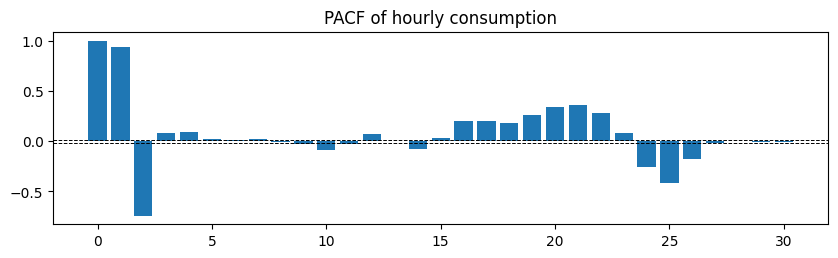

PACF lags 1-4: [ 0.935 -0.739  0.078  0.09 ] | lag 24: -0.253 | lag 25: -0.411


In [4]:
def lag_matrix(x, lags):
    x = np.asarray(x, dtype=float)
    cols = [x[max(lags) - k: len(x) - k] for k in lags]
    return np.column_stack(cols), x[max(lags):]

def pacf(x, nlags):
    out = [1.0]
    for k in range(1, nlags + 1):
        X, y = lag_matrix(x, list(range(1, k + 1)))
        X1 = np.column_stack([np.ones(len(y)), X])
        beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
        out.append(beta[-1])
    return np.array(out)

p = pacf(cons, 30)
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.bar(range(31), p, width=0.8); ax.axhline(band, color="k", ls="--", lw=0.7); ax.axhline(-band, color="k", ls="--", lw=0.7)
ax.set_title("PACF of hourly consumption"); plt.show()
print("PACF lags 1-4:", p[1:5].round(3), "| lag 24:", round(p[24], 3), "| lag 25:", round(p[25], 3))

## 3. Stationarity intuition without a unit-root test

A stationary series has a mean, variance and autocorrelation that do not depend on
time. The cheap checks: rolling mean and std, first half vs second half, and the
variance-ratio idea (for a random walk, the variance of k-step changes grows like k;
for a stationary series it saturates).

In [5]:
roll = pd.DataFrame({"mean_30d": cons.rolling(24 * 30).mean(), "std_30d": cons.rolling(24 * 30).std()})
half = len(cons) // 2
print("mean first half / second half:", round(cons.iloc[:half].mean()), round(cons.iloc[half:].mean()))
print("std  first half / second half:", round(cons.iloc[:half].std()), round(cons.iloc[half:].std()))
print("price mean first / second half:", round(price.iloc[:half].mean(), 1), round(price.iloc[half:].mean(), 1))

def variance_ratio(x, ks):
    x = np.asarray(x, dtype=float)
    v1 = np.var(np.diff(x))
    return {k: np.var(x[k:] - x[:-k]) / (k * v1) for k in ks}

rw = np.cumsum(np.random.default_rng(0).normal(size=len(cons)))
pd.DataFrame({"consumption": variance_ratio(cons, [2, 6, 24, 168]),
              "price": variance_ratio(price, [2, 6, 24, 168]),
              "random_walk": variance_ratio(rw, [2, 6, 24, 168])}).round(2).T

mean first half / second half: 29407 29223
std  first half / second half: 4237 4171
price mean first / second half: 112.3 84.8


,2,6,24,168
consumption,1.68,2.35,0.05,0.01
price,0.71,0.50,0.06,0.01
random_walk,1.00,1.01,1.05,1.10


Reading the table: a random walk has VR ≈ 1 at every horizon. Consumption is above 1 at
2-6 hours (the smooth daily ramp makes consecutive changes positively correlated) and
collapses towards 0 at 24 and 168 hours: the series returns to its cycle, it does not
wander. Price is below 1 everywhere: hourly changes mean-revert, and even the 2022 gas
regime is not a random walk at these horizons.

### Differencing

`diff(1)` removes a slowly moving level, `diff(24)` removes the daily pattern,
`diff(168)` the weekly one. Each differencing also **adds** negative autocorrelation at
that lag (over-differencing shows up as ACF ≈ −0.5 at lag 1).

In [6]:
white = pd.Series(np.random.default_rng(1).normal(size=5000))
rows = {}
for name, s in {"levels": cons, "diff1": cons.diff(1), "diff24": cons.diff(24),
                "diff1_of_diff24": cons.diff(24).diff(1), "white noise diff1 (over-diff)": white.diff(1)}.items():
    r = acf(s.dropna(), 168)
    rows[name] = {"acf1": r[1], "acf2": r[2], "acf24": r[24], "acf168": r[168]}
pd.DataFrame(rows).T.round(3)

,acf1,acf2,acf24,acf168
levels,0.935,0.781,0.913,0.920
diff1,0.682,0.337,0.861,0.875
diff24,0.896,0.806,-0.226,0.411
diff1_of_diff24,-0.069,-0.059,-0.452,0.160
white noise diff1 (over-diff),-0.503,0.004,0.024,0.007


### Log transform for multiplicative series

If the seasonal swing scales with the level (prices, sales), model `log(x)`. Not
possible when the series can be ≤ 0, which is exactly the case for power prices.

**Pitfall:** `np.log` of a negative price gives NaN silently. Check `(x <= 0).sum()`
first; use `log1p` on a shifted series or model the level directly.

Below, the log transform makes the two years *less* comparable: 2023 has a lower level
with similar absolute swings, so its log-volatility is higher. A transform is a modelling
claim, check it rather than apply it by habit.

In [7]:
print("non-positive prices:", (price <= 0).sum())
lp = np.log(price.where(price > 0))
print("NaN after log:", lp.isna().sum())
print("std of price by year:", price.groupby(price.index.year).std().round(1).to_dict())
print("std of log price by year:", lp.groupby(lp.index.year).std().round(3).to_dict())

non-positive prices: 43
NaN after log: 43
std of price by year: {2022: 33.8, 2023: 34.6}
std of log price by year: {2022: 0.324, 2023: 0.487}


## 4. Seasonal decomposition by hand

Classical additive decomposition: `trend` = centred moving average over one week,
`seasonal` = mean of the detrended series by (day-of-week, hour), `residual` = the rest.
Then look at the residual ACF: whatever structure is left is what your model still
has to explain.

{'observed': 4208.0, 'trend': 1891.0, 'seasonal': 3612.0, 'residual': 998.0}
residual ACF lags 1,2,3,24: [0.864 0.743 0.633 0.135]


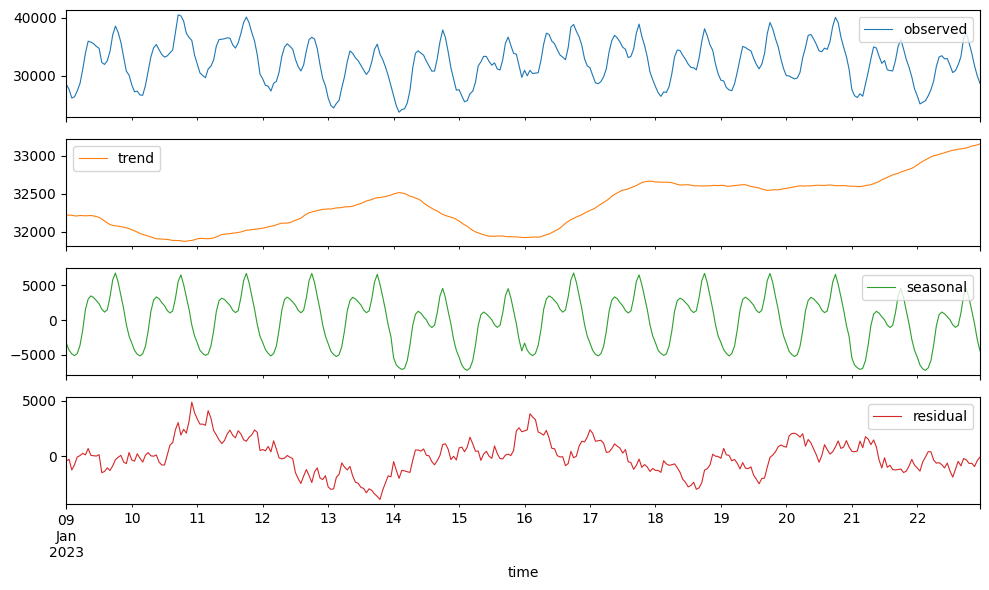

In [8]:
trend = cons.rolling(168, center=True).mean()
detr = cons - trend
key = [cons.index.dayofweek, cons.index.hour]
seasonal = detr.groupby(key).transform("mean")
resid = detr - seasonal
dec = pd.DataFrame({"observed": cons, "trend": trend, "seasonal": seasonal, "residual": resid})
print(dec.dropna().std().round(0).to_dict())
r = acf(resid.dropna(), 48)
print("residual ACF lags 1,2,3,24:", r[[1, 2, 3, 24]].round(3))
dec.loc["2023-01-09":"2023-01-22"].plot(subplots=True, figsize=(10, 6), lw=0.8); plt.tight_layout(); plt.show()

### Regression decomposition

The same idea as a linear model: hour×dow dummies plus a linear trend. It gives a
residual with a meaning ("what a calendar model cannot explain") and it extrapolates,
which the moving average cannot.

In [9]:
cal = pd.DataFrame({"t": np.arange(len(cons)) / 8760.0, "hd": cons.index.dayofweek * 24 + cons.index.hour}, index=cons.index)
X_cal = pd.get_dummies(cal["hd"], prefix="hd", dtype=float).assign(t=cal["t"])
lr = LinearRegression().fit(X_cal, cons)
resid_reg = cons - lr.predict(X_cal)
print("trend coefficient (MWh per year):", round(lr.coef_[-1]))
print("residual std: moving-average decomposition", round(resid.std()), "| regression", round(resid_reg.std()))
print("residual ACF lag 1 / 24:", acf(resid_reg, 24)[[1, 24]].round(3))

trend coefficient (MWh per year): -633
residual std: moving-average decomposition 998 | regression 2129
residual ACF lag 1 / 24: [0.97  0.807]


The regression residual is twice as large as the moving-average one and far more
persistent (ACF 0.97 at lag 1). The moving average tracks the level whatever causes it;
the calendar regression cannot absorb weather, so the heating effect is left in the
residual. That is not a failure: it is the residual you *want* to model with temperature
and lags.

**Interview check:** "The residual still has ACF 0.8 at lag 1. What does that tell you?"
The calendar explains the shape but not the persistence: whatever pushed load up this
hour is still there next hour (weather, a slow noise process). A lag-1 term, or the
weather itself, belongs in the model.

## 5. AR models via OLS

An AR(p) is just a regression of x_t on its own lags. Fit with `np.linalg.lstsq`, look
at the coefficients and the residual ACF. Fit on 2022, evaluate on 2023.

In [10]:
y_all = resid_reg.copy()
train_end = "2022-12-31 23:00+00:00"

def fit_ar(series, lags, end):
    X, y = lag_matrix(series, lags)
    idx = series.index[max(lags):]
    X = np.column_stack([np.ones(len(y)), X])
    m = idx <= pd.Timestamp(end)
    beta, *_ = np.linalg.lstsq(X[m], y[m], rcond=None)
    return beta, X, y, idx

for lags in ([1], [1, 2], [1, 24], [1, 2, 24, 168]):
    beta, X, y, idx = fit_ar(y_all, lags, train_end)
    pred = X @ beta
    test = idx > pd.Timestamp(train_end)
    e = y[test] - pred[test]
    print(f"AR lags {str(lags):16s} coef {np.round(beta[1:], 3)}  test RMSE {np.sqrt(np.mean(e**2)):7.1f}  resid ACF1 {acf(e, 1)[1]:.3f}")

AR lags [1]              coef [0.972]  test RMSE   519.4  resid ACF1 -0.048
AR lags [1, 2]           coef [0.931 0.042]  test RMSE   518.9  resid ACF1 -0.009
AR lags [1, 24]          coef [0.917 0.067]  test RMSE   512.2  resid ACF1 -0.021
AR lags [1, 2, 24, 168]  coef [0.892 0.013 0.053 0.032]  test RMSE   510.7  resid ACF1 -0.002


### One-step vs multi-step (recursive) forecasts

An AR(1) with coefficient φ forecasts h steps ahead as mean + φ^h × (last deviation).
The one-step RMSE is flattering; the error grows with horizon towards the unconditional
standard deviation. "Persistence" here means carrying today's residual forward unchanged
(calendar forecast plus the current deviation): the baseline to beat at every horizon.

In [11]:
beta1, X1, y1, idx1 = fit_ar(y_all, [1], train_end)
c, phi = beta1
test = idx1 > pd.Timestamp(train_end)
y_test = y1[test]
rows = []
for h in [1, 2, 6, 12, 24, 48]:
    # forecast made at t for t+h, recursively: mean + phi^h (x_t - mean)
    mu = c / (1 - phi)
    x_t = y_test[:-h]
    fc = mu + phi ** h * (x_t - mu)
    actual = y_test[h:]
    rows.append({"h": h, "AR1_rmse": np.sqrt(np.mean((actual - fc) ** 2)),
                 "persistence_rmse": np.sqrt(np.mean((actual - x_t) ** 2)),
                 "phi^h": phi ** h})
pd.DataFrame(rows).set_index("h").round(3).assign(uncond_std=round(y_test.std(), 1))

,AR1_rmse,persistence_rmse,phi^h,uncond_std
h,,,,
1,519.468,523.510,0.972,2055.8
2,706.815,717.293,0.944,2055.8
6,1079.733,1119.526,0.842,2055.8
12,1287.529,1344.661,0.708,2055.8
24,1400.027,1310.379,0.501,2055.8
48,1734.589,1457.693,0.251,2055.8


At 24 and 48 hours the AR(1) is *worse* than persistence: φ^24 shrinks the deviation
towards zero, but the real residual keeps a daily structure (weather persists across
days) that a single lag cannot see. The fix is a seasonal lag (24, 168) or the weather
itself, not a bigger φ.

## 6. Exponential smoothing by hand

Simple exponential smoothing: level_t = α·x_t + (1−α)·level_{t−1}, forecast = level.
`ewm(alpha=α, adjust=False).mean()` does exactly this. Holt adds a trend term; here it
is written as a loop so the recursion is visible. Choose α by minimising one-step SSE on
the training window.

**Pitfall:** `ewm(span=…)` and `ewm(halflife=…)` are alternative parameterisations of the
same α; `adjust=True` (the default) reweights early observations and is *not* the
textbook recursion.

In [12]:
daily = cons.resample("D").mean()
train = daily.loc[:"2022-12-31"]

def ses_sse(alpha, x):
    level = x.ewm(alpha=alpha, adjust=False).mean()
    fc = level.shift(1)
    return ((x - fc).dropna() ** 2).sum()

res = minimize_scalar(ses_sse, bounds=(0.01, 0.99), args=(train,), method="bounded")
alpha = res.x
print(f"alpha* = {alpha:.3f}  (success={res.success})")

def holt(x, alpha, beta):
    level, trend = x.iloc[0], 0.0
    out = []
    for v in x.iloc[1:]:
        out.append(level + trend)                      # forecast made before seeing v
        new_level = alpha * v + (1 - alpha) * (level + trend)
        trend = beta * (new_level - level) + (1 - beta) * trend
        level = new_level
    return pd.Series(out, index=x.index[1:])

test_d = daily.loc["2023-01-01":]
ses_fc = daily.ewm(alpha=alpha, adjust=False).mean().shift(1).loc[test_d.index]
holt_fc = holt(daily, alpha, 0.05).loc[test_d.index]
naive_fc = daily.shift(1).loc[test_d.index]
weekly_fc = daily.shift(7).loc[test_d.index]
pd.Series({"naive": np.sqrt(np.mean((test_d - naive_fc) ** 2)),
           "seasonal naive (7d)": np.sqrt(np.mean((test_d - weekly_fc) ** 2)),
           "SES": np.sqrt(np.mean((test_d - ses_fc) ** 2)),
           "Holt": np.sqrt(np.mean((test_d - holt_fc) ** 2))}, name="daily RMSE 2023").round(0)

alpha* = 0.156  (success=True)


naive                  1333.0
seasonal naive (7d)    1181.0
SES                    1263.0
Holt                   1272.0
Name: daily RMSE 2023, dtype: float64

## 7. Cross-correlation and lead-lag

`ccf(k) = corr(x_t, y_{t+k})`. Positive k means "x now vs y later": if the peak is at
k > 0, **x leads y**. Get the sign convention wrong and you conclude that demand
predicts the weather. Work on residuals (calendar removed) so the shared daily cycle does
not dominate.

strongest (most negative) cross-correlation -0.896 at k = +0


k = 0: -0.896 | k = +3: -0.886 | k = -3: -0.884


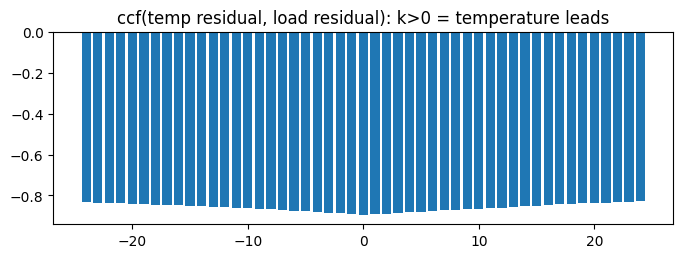

In [13]:
temp_res = temp - temp.groupby([temp.index.dayofweek, temp.index.hour]).transform("mean")
x = temp_res.to_numpy(); y = resid_reg.to_numpy()

def ccf(x, y, k):
    # corr(x_t, y_{t+k}); k > 0 -> x leads y
    if k >= 0:
        return np.corrcoef(x[:len(x) - k], y[k:])[0, 1]
    return np.corrcoef(x[-k:], y[:len(y) + k])[0, 1]

lags = np.arange(-24, 25)
cc = np.array([ccf(x, y, k) for k in lags])
best = lags[np.argmin(cc)]     # heating: colder -> higher load, so the correlation is negative
print(f"strongest (most negative) cross-correlation {cc.min():.3f} at k = {best:+d}")
print("k = 0:", round(cc[lags == 0][0], 3), "| k = +3:", round(cc[lags == 3][0], 3), "| k = -3:", round(cc[lags == -3][0], 3))
fig, ax = plt.subplots(figsize=(8, 2.5)); ax.bar(lags, cc); ax.set_title("ccf(temp residual, load residual): k>0 = temperature leads"); plt.show()

The peak is at k = 0: in this synthetic data load responds to temperature within the
hour. Real buildings have thermal inertia, so the peak sits at k = +2..+6 (temperature
leads load). If you had found the peak at k < 0 you would be claiming load predicts the
weather, which is the sign convention error to watch for.

### Granger-style test with a nested F-test

Does temperature help predict load beyond load's own lags? Compare RSS of a restricted
model (own lags) with the unrestricted (own lags + temperature lags). F = ((RSS_r − RSS_u)/q) / (RSS_u/(n − k)).

**Pitfall:** "Granger causes" means "helps predict", not "causes". And with n = 17,000
hourly observations almost any extra lag is "significant"; report the RMSE change too.

In [14]:
def design(series_dict, lags):
    cols, names = [], []
    L = max(lags)
    for name, s in series_dict.items():
        s = np.asarray(s, float)
        for k in lags:
            cols.append(s[L - k: len(s) - k]); names.append(f"{name}_l{k}")
    target = np.asarray(series_dict["load"], float)[L:]
    return np.column_stack([np.ones(len(target))] + cols), target, names

lag_set = [1, 2, 3, 24]
Xu, yy, names = design({"load": resid_reg, "temp": temp_res}, lag_set)
Xr = Xu[:, [0] + [i + 1 for i, n in enumerate(names) if n.startswith("load")]]
def rss(X, y):
    b, *_ = np.linalg.lstsq(X, y, rcond=None); return ((y - X @ b) ** 2).sum()
rss_u, rss_r = rss(Xu, yy), rss(Xr, yy)
q, k, n = len(lag_set), Xu.shape[1], len(yy)
F = ((rss_r - rss_u) / q) / (rss_u / (n - k))
print(f"F = {F:.1f}, p = {1 - stats.f.cdf(F, q, n - k):.2e}")
print(f"RMSE restricted {np.sqrt(rss_r / n):.1f} -> unrestricted {np.sqrt(rss_u / n):.1f}")

F = 135.4, p = 1.11e-16
RMSE restricted 510.0 -> unrestricted 502.3


## 8. Spurious regression

Two independent random walks regressed on each other give a large R² and a huge
t-statistic. In first differences the relationship disappears. Any regression of one
trending level on another (2022 gas-driven prices vs anything that also drifted) has
this problem.

In [15]:
rng = np.random.default_rng(7)
n = 2000
a = np.cumsum(rng.normal(size=n)); b = np.cumsum(rng.normal(size=n))
def ols_t(x, y):
    X = np.column_stack([np.ones(len(x)), x])
    beta, res, *_ = np.linalg.lstsq(X, y, rcond=None)
    e = y - X @ beta; s2 = (e @ e) / (len(y) - 2)
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[1, 1])
    r2 = 1 - (e @ e) / ((y - y.mean()) @ (y - y.mean()))
    return beta[1], beta[1] / se, r2
for label, (x, y) in {"levels": (a, b), "differences": (np.diff(a), np.diff(b))}.items():
    beta, t, r2 = ols_t(x, y)
    print(f"{label:12s} beta {beta:7.3f}  t {t:7.1f}  R² {r2:.3f}")

levels       beta  -0.123  t   -15.5  R² 0.107
differences  beta   0.008  t     0.3  R² 0.000


In [16]:
# the same pattern in the data: 2022 price level vs a linear time trend
t_idx = np.arange(len(price))
p22 = price.loc["2022"]; t22 = t_idx[: len(p22)]
print("price on time trend, 2022 levels:  beta %.4f  t %.1f  R² %.3f" % ols_t(t22, p22.to_numpy()))
print("price on time trend, 2022 changes: beta %.4f  t %.1f  R² %.3f" % ols_t(t22[1:], p22.diff().dropna().to_numpy()))

price on time trend, 2022 levels:  beta 0.0056  t 43.3  R² 0.176


price on time trend, 2022 changes: beta -0.0000  t -0.0  R² 0.000


## 9. Volatility clustering in price changes

Price changes have little autocorrelation but their **squares** do: big moves cluster
(the 2022 spike). Consequences: a single RMSE across 2022-2023 is dominated by the
high-vol regime, and iid confidence intervals are wrong.

In [17]:
dp = price.diff().dropna()
r_dp = acf(dp, 24); r_dp2 = acf(dp ** 2, 24)
print("ACF of price changes  lags 1,2,24:", r_dp[[1, 2, 24]].round(3))
print("ACF of squared changes lags 1,2,24:", r_dp2[[1, 2, 24]].round(3))
vol = dp.rolling(24 * 7).std()
print("rolling weekly std of hourly changes: 2022 median %.1f, 2023 median %.1f" % (vol.loc["2022"].median(), vol.loc["2023"].median()))
print("share of total squared change in 2022:", round((dp.loc["2022"] ** 2).sum() / (dp ** 2).sum(), 3))

ACF of price changes  lags 1,2,24: [-0.291  0.038  0.159]
ACF of squared changes lags 1,2,24: [ 0.467 -0.006  0.025]
rolling weekly std of hourly changes: 2022 median 21.2, 2023 median 22.3
share of total squared change in 2022: 0.487


## 10. Error vs forecast horizon

The honest summary of any forecasting exercise: a table of RMSE by horizon for the
naive baselines and your model. Here: persistence, seasonal naive (24h), AR(24) on the
calendar residual, and the calendar regression alone. Forecast origin t, target t+h,
2023 only.

In [18]:
cal_pred = pd.Series(lr.predict(X_cal), index=cons.index)     # calendar model, known for any future hour
beta24, X24, y24, idx24 = fit_ar(resid_reg, [1, 2, 24], train_end)

def ar_recursive(s, beta, lags, h):
    # forecast of x_{t+h} made at origin t, for every t, using an AR on lags `lags`
    # regressor for lag k at step `step` is x_{t+step-k}: known (shift(k-step)) if k >= step, else the step-k forecast
    preds = {}
    for step in range(1, h + 1):
        p = pd.Series(beta[0], index=s.index)
        for i, k in enumerate(lags):
            reg = s.shift(k - step) if k >= step else preds[step - k]
            p = p + beta[i + 1] * reg
        preds[step] = p
    return preds[h]

rows = []
test_mask = cons.index > pd.Timestamp(train_end)
for h in [1, 6, 12, 24, 48, 168]:
    actual = cons.shift(-h)
    persist = cons
    seasonal = cons.shift((24 - h) % 24)                 # latest same-hour-of-day value known at t
    ar_res = ar_recursive(resid_reg, beta24, [1, 2, 24], h)
    ar_fc = cal_pred.shift(-h) + ar_res
    cal_only = cal_pred.shift(-h)
    m = test_mask & actual.notna()
    def rmse(f): 
        e = (actual - f)[m].dropna(); return np.sqrt((e ** 2).mean())
    rows.append({"h": h, "persistence": rmse(persist), "seasonal_naive": rmse(seasonal),
                 "calendar_only": rmse(cal_only), "calendar+AR": rmse(ar_fc)})
pd.DataFrame(rows).set_index("h").round(0)

,persistence,seasonal_naive,calendar_only,calendar+AR
h,,,,
1,1519.0,1696.0,2068.0,512.0
6,5707.0,1696.0,2068.0,999.0
12,6072.0,1697.0,2068.0,1129.0
24,1697.0,1697.0,2067.0,1174.0
48,2094.0,2094.0,2066.0,1298.0
168,1591.0,1591.0,2057.0,1639.0


**Interview check:** "Your model beats persistence at h = 1 but not at h = 24. Is it
useful?" Depends on the decision: a day-ahead trader needs h = 12–36, so the h = 1
result is irrelevant to them. Always state which horizon the decision needs before
quoting a metric.

## Quick reference

| Concept | By hand |
|---|---|
| ACF(k) | `x=x-x.mean(); (x[k:]@x[:-k]) / (x@x)` |
| white-noise band | `±1.96/np.sqrt(n)` (only under H0 of no autocorrelation) |
| PACF(k) | last coefficient of OLS of x_t on lags 1..k |
| variance ratio | `var(x[k:]-x[:-k]) / (k*var(diff(x)))` ≈ 1 for a random walk |
| decomposition | trend = centred rolling mean; seasonal = mean by (dow, hour) of detrended; residual = rest |
| AR(p) | `np.linalg.lstsq` on a lag matrix; check residual ACF |
| h-step AR(1) | `mu + phi**h * (x_t - mu)` |
| SES | `x.ewm(alpha=a, adjust=False).mean().shift(1)` |
| ccf(k) | `corr(x[:-k], y[k:])`, k>0 means x leads y |
| Granger F | `((RSS_r-RSS_u)/q) / (RSS_u/(n-k))` |
| spurious regression | high R², huge t in levels; vanishes in differences |
| volatility clustering | ACF of squared changes ≫ ACF of changes |